In [95]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops
from torch_geometric.nn import MessagePassing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [96]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

In [97]:
print('Total number of training nodes before split: ',data.train_mask.sum())
print('Total number of training nodes before split: ',data.test_mask.sum())
print('Total number of training nodes before split: ',data.val_mask.sum())


Total number of training nodes before split:  tensor(140)
Total number of training nodes before split:  tensor(1000)
Total number of training nodes before split:  tensor(500)


In [98]:
data.x

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [99]:
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)  # random shuffle
train_size = int(0.7 * num_nodes)
val_size   = int(0.15 * num_nodes)
test_size  = num_nodes - train_size - val_size
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Train nodes: 1895
Validation nodes: 406
Test nodes: 407


In [100]:
class NeutrosophicFuzzification(nn.Module):
    def __init__(self, alpha=0.5, beta=2.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, x):
        mean = x.mean(dim=0, keepdim=True)
        std = x.std(dim=0, keepdim=True) + 1e-6

        T = torch.exp(-((x - mean)**2) / (2 * std**2))
        F_val = 1 - torch.exp(-((x - mean)**2) / (2 * (self.alpha * std)**2))
        I = 1 - torch.exp(-((x - mean)**2) / (2 * (self.beta * std)**2))

        return T, I, F_val


In [101]:
class NGNNLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')  # ✅ sum aggregation (IMPORTANT)

        self.W_T = nn.Linear(in_channels, out_channels)
        self.W_I = nn.Linear(in_channels, out_channels)
        self.W_F = nn.Linear(in_channels, out_channels)

    def forward(self, T, I, F_val, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=T.size(0))

        row, col = edge_index

        # 🔹 Step 1: cosine similarity (edge feature)
        edge_sim = F.cosine_similarity(T[row], T[col], dim=1)

        # 🔹 Step 2: fuzzify edge weights
        edge_T, edge_I, edge_F = self.fuzzify_edge(edge_sim)

        # 🔹 Step 3: transform node features
        T_trans = self.W_T(T)
        I_trans = self.W_I(I)
        F_trans = self.W_F(F_val)

        # 🔹 Step 4: aggregation using fuzzy edge weights
        T_agg = self.propagate(edge_index, x=T_trans, edge_weight=edge_T)
        I_agg = self.propagate(edge_index, x=I_trans, edge_weight=edge_I)
        F_agg = self.propagate(edge_index, x=F_trans, edge_weight=edge_F)

        # 🔹 Step 5: combine (residual-style)
        T_new = T_trans + T_agg
        I_new = I_trans + I_agg
        F_new = F_trans + F_agg

        return T_new, I_new, F_new

    def message(self, x_j, edge_weight):
        # ✅ Implements: neighbor_value × edge_value
        return edge_weight.view(-1, 1) * x_j

    def fuzzify_edge(self, edge_weight, beta=2.0):
        # Normalize cosine similarity [-1,1] → [0,1]
        w = (edge_weight + 1) / 2

        T_e = w                              # Truth
        I_e = torch.exp(-beta * (w - 0.5)**2)  # Indeterminacy
        F_e = 1 - w                          # Falsity

        return T_e, I_e, F_e

In [102]:
class NGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        self.fuzz = NeutrosophicFuzzification()

        self.layer1 = NGNNLayer(in_channels, hidden_channels)
        self.layer2 = NGNNLayer(hidden_channels, out_channels)
        # Learnable rule strengths
        self.rule_weights = nn.Parameter(torch.tensor([1.0, 1.0, 1.0]))


    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Step 1: Fuzzification
        T, I, F_val = self.fuzz(x)

        # Step 2: Layer 1
        T, I, F_val = self.layer1(T, I, F_val, edge_index)
        T, I, F_val = F.relu(T), F.relu(I), F.relu(F_val)

        # Step 3: Layer 2
        T, I, F_val = self.layer2(T, I, F_val, edge_index)

        # Step 4: Normalize rule strengths
        weights = torch.softmax(self.rule_weights, dim=0)

        # Step 5: Defuzzification
        H = weights[0]*T + weights[1]*I + weights[2]*F_val

        return H,F.log_softmax(H, dim=1)

In [103]:

T, I, F_val = model.fuzz(data.x)

print("Truth (T) for first 5 nodes:\n", T[:5])
print("\nIndeterminacy (I) for first 5 nodes:\n", I[:5])
print("\nFalsity (F) for first 5 nodes:\n", F_val[:5])

Truth (T) for first 5 nodes:
 tensor([[0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978],
        [0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978],
        [0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978],
        [0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978],
        [0.9970, 0.9939, 0.9868,  ..., 0.9989, 0.9878, 0.9978]])

Indeterminacy (I) for first 5 nodes:
 tensor([[0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006],
        [0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006],
        [0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006],
        [0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006],
        [0.0007, 0.0015, 0.0033,  ..., 0.0003, 0.0031, 0.0006]])

Falsity (F) for first 5 nodes:
 tensor([[0.0118, 0.0244, 0.0517,  ..., 0.0044, 0.0480, 0.0089],
        [0.0118, 0.0244, 0.0517,  ..., 0.0044, 0.0480, 0.0089],
        [0.0118, 0.0244, 0.0517,  ..., 0.0044, 0.0480, 0.0089],
        [0.0118, 0.0244, 0.0517,  ..., 0.0044, 0.0480, 0.0089],


In [104]:
device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
model = NGNN(
    in_channels=dataset.num_node_features,
    hidden_channels=16,
    out_channels=dataset.num_classes
).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [105]:
def train():
    model.train()
    optimizer.zero_grad()
    H,out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test():
    model.eval()
    with torch.no_grad():
        H, out = model(data)   # 👈 unpack tuple
        
        pred = out.argmax(dim=1)

        correct = pred[data.test_mask] == data.y[data.test_mask]
        acc = int(correct.sum()) / int(data.test_mask.sum())

    return acc

In [106]:
for epoch in range(1, 501):
    loss = train()
    acc = test()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

Epoch 10, Loss: 6.3054, Test Accuracy: 0.2727
Epoch 20, Loss: 1.6499, Test Accuracy: 0.4889
Epoch 30, Loss: 0.9735, Test Accuracy: 0.6904
Epoch 40, Loss: 0.7812, Test Accuracy: 0.7518
Epoch 50, Loss: 0.6379, Test Accuracy: 0.7740
Epoch 60, Loss: 0.5527, Test Accuracy: 0.7936
Epoch 70, Loss: 0.4822, Test Accuracy: 0.7985
Epoch 80, Loss: 0.4226, Test Accuracy: 0.8108
Epoch 90, Loss: 0.3732, Test Accuracy: 0.8157
Epoch 100, Loss: 0.3295, Test Accuracy: 0.8231
Epoch 110, Loss: 0.2909, Test Accuracy: 0.8206
Epoch 120, Loss: 0.2460, Test Accuracy: 0.8206
Epoch 130, Loss: 0.1965, Test Accuracy: 0.8256
Epoch 140, Loss: 0.1597, Test Accuracy: 0.8256
Epoch 150, Loss: 0.1332, Test Accuracy: 0.8280
Epoch 160, Loss: 0.1146, Test Accuracy: 0.8305
Epoch 170, Loss: 0.1011, Test Accuracy: 0.8305
Epoch 180, Loss: 0.0906, Test Accuracy: 0.8329
Epoch 190, Loss: 0.0825, Test Accuracy: 0.8305
Epoch 200, Loss: 0.0755, Test Accuracy: 0.8329
Epoch 210, Loss: 0.0698, Test Accuracy: 0.8329
Epoch 220, Loss: 0.065

In [114]:
def get_embeddings():
    model.eval()
    with torch.no_grad():
        H, out = model(data)
    return H

In [115]:
H = get_embeddings()

print("Shape of X_new:", H.shape)
print("\nFirst 5 nodes (X_new):\n", H[:5])

Shape of X_new: torch.Size([2708, 7])

First 5 nodes (X_new):
 tensor([[-1.2649e+00, -4.3771e-01,  2.1297e+00,  8.2453e+00, -2.2419e+00,
         -1.4767e+00, -3.2717e+00],
        [ 1.4478e+00, -3.3530e+00, -6.7386e+00,  7.6151e-03,  8.2789e+00,
         -6.1132e+00, -1.9459e+00],
        [ 2.3782e+00, -3.6742e+00, -5.7906e+00,  4.0380e+00,  8.0866e+00,
         -9.0804e+00, -5.9463e+00],
        [ 3.5196e+00, -4.1290e+00, -1.6661e+00, -4.7727e-01,  3.1153e-01,
         -1.9229e+00,  1.3212e-01],
        [-2.3433e+00,  5.4144e-01,  2.5759e+00,  9.3310e+00, -2.6264e+00,
         -1.6557e+00, -4.7730e+00]])


In [116]:
def get_predictions():
    model.eval()
    with torch.no_grad():
        H, out = model(data)
        pred = out.argmax(dim=1)
    return pred

In [117]:
pred = get_predictions()

print("First 20 nodes classification:\n")
for i in range(50):
    print(f"Node {i}: Predicted = {pred[i].item()}, Actual = {data.y[i].item()}")

First 20 nodes classification:

Node 0: Predicted = 3, Actual = 3
Node 1: Predicted = 4, Actual = 4
Node 2: Predicted = 4, Actual = 4
Node 3: Predicted = 0, Actual = 0
Node 4: Predicted = 3, Actual = 3
Node 5: Predicted = 2, Actual = 2
Node 6: Predicted = 0, Actual = 0
Node 7: Predicted = 3, Actual = 3
Node 8: Predicted = 3, Actual = 3
Node 9: Predicted = 2, Actual = 2
Node 10: Predicted = 1, Actual = 0
Node 11: Predicted = 0, Actual = 0
Node 12: Predicted = 4, Actual = 4
Node 13: Predicted = 3, Actual = 3
Node 14: Predicted = 3, Actual = 3
Node 15: Predicted = 3, Actual = 3
Node 16: Predicted = 2, Actual = 2
Node 17: Predicted = 3, Actual = 3
Node 18: Predicted = 1, Actual = 1
Node 19: Predicted = 3, Actual = 3
Node 20: Predicted = 5, Actual = 5
Node 21: Predicted = 3, Actual = 3
Node 22: Predicted = 4, Actual = 4
Node 23: Predicted = 6, Actual = 6
Node 24: Predicted = 3, Actual = 3
Node 25: Predicted = 3, Actual = 3
Node 26: Predicted = 6, Actual = 6
Node 27: Predicted = 3, Actual = 

In [118]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def evaluate_metrics():
    model.eval()
    with torch.no_grad():
        H, out = model(data)
        pred = out.argmax(dim=1).cpu()
        true = data.y.cpu()

        # Only consider test nodes
        test_idx = data.test_mask.cpu()
        y_true = true[test_idx]
        y_pred = pred[test_idx]

        # Compute metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')  # macro = average over classes
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

    return acc, precision, recall, f1, cm

In [121]:
# After training is done
acc, precision, recall, f1, cm = evaluate_metrics()

print(f"Test Accuracy  : {acc:.4f}")
print(f"Test Precision : {precision:.4f}")
print(f"Test Recall    : {recall:.4f}")
print(f"Test F1 Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

Test Accuracy  : 0.8280
Test Precision : 0.8341
Test Recall    : 0.8137
Test F1 Score  : 0.8182

Confusion Matrix:
[[ 43   1   0  12   1   1   1]
 [  1  32   1   4   0   0   0]
 [  0   4  57   6   0   1   0]
 [  2   2   1 109   5   0   1]
 [  1   0   0   4  41   0   0]
 [  1   0   3   3   0  31   9]
 [  5   0   0   0   0   0  24]]


In [119]:
data.y[20].item()

5

In [120]:
# Make predictions
model.eval()
with torch.no_grad():
    H, out = model(data)
    pred = out.argmax(dim=1)

# Only consider test nodes
test_idx = data.test_mask.nonzero(as_tuple=True)[0]
y_true = data.y[test_idx]
y_pred = pred[test_idx]

# Find misclassified nodes
wrong_idx = test_idx[y_true != y_pred]

print(f"Total wrong predictions in test set: {len(wrong_idx)}\n")
print("List of misclassified nodes (Node ID : Predicted -> Actual):")
for node in wrong_idx:
    print(f"Node {node.item()}: Pred = {y_pred[node == test_idx].item()}, Actual = {y_true[node == test_idx].item()}")

Total wrong predictions in test set: 70

List of misclassified nodes (Node ID : Predicted -> Actual):
Node 55: Pred = 0, Actual = 4
Node 77: Pred = 0, Actual = 6
Node 94: Pred = 4, Actual = 0
Node 98: Pred = 3, Actual = 0
Node 131: Pred = 2, Actual = 1
Node 250: Pred = 3, Actual = 4
Node 266: Pred = 0, Actual = 5
Node 349: Pred = 6, Actual = 5
Node 365: Pred = 3, Actual = 0
Node 382: Pred = 4, Actual = 3
Node 417: Pred = 1, Actual = 3
Node 419: Pred = 6, Actual = 5
Node 446: Pred = 6, Actual = 0
Node 474: Pred = 3, Actual = 5
Node 493: Pred = 1, Actual = 2
Node 528: Pred = 6, Actual = 5
Node 548: Pred = 3, Actual = 1
Node 554: Pred = 1, Actual = 3
Node 626: Pred = 1, Actual = 2
Node 733: Pred = 3, Actual = 0
Node 767: Pred = 3, Actual = 0
Node 822: Pred = 6, Actual = 5
Node 852: Pred = 3, Actual = 0
Node 862: Pred = 3, Actual = 4
Node 872: Pred = 3, Actual = 4
Node 896: Pred = 6, Actual = 5
Node 950: Pred = 0, Actual = 6
Node 1036: Pred = 3, Actual = 0
Node 1070: Pred = 5, Actual = 2
N

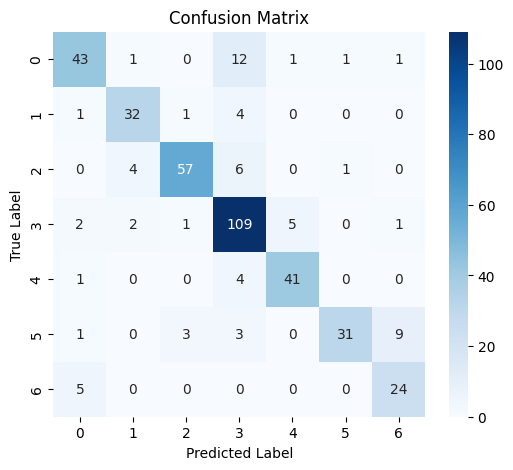

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

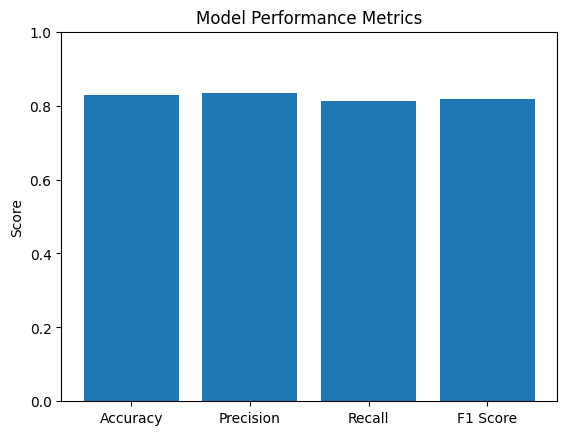

In [124]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [acc, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()

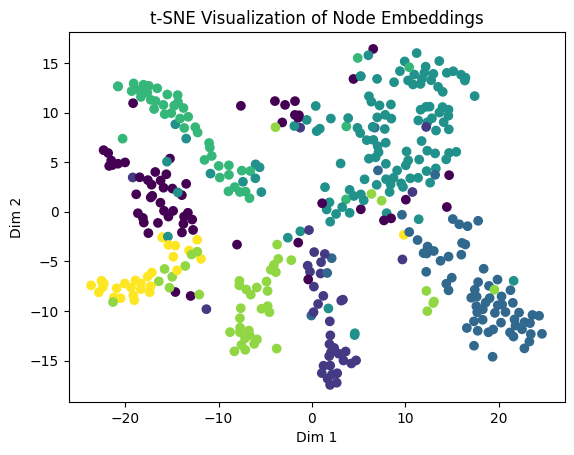

In [125]:
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    H, out = model(data)   # H = embeddings

# Take only test nodes
test_idx = data.test_mask.cpu()
H_test = H[test_idx].cpu().numpy()
y_test = data.y[test_idx].cpu().numpy()

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42)
H_2d = tsne.fit_transform(H_test)

# Plot
plt.figure()
plt.scatter(H_2d[:,0], H_2d[:,1], c=y_test)

plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

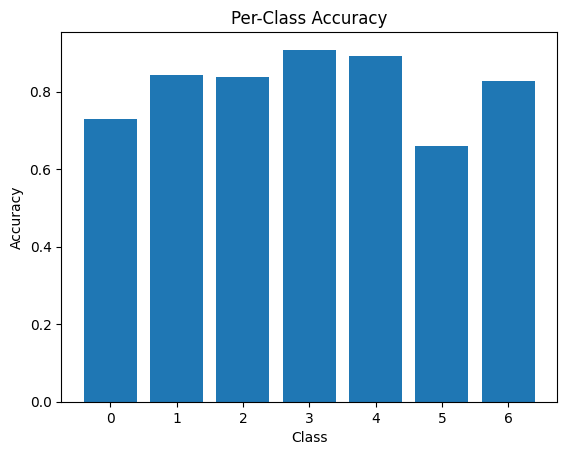

In [126]:
import numpy as np

num_classes = cm.shape[0]
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar(range(num_classes), class_acc)

plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")

plt.show()